
--- PERMANOVA Summary Table (Genome Level) ---
    level    host_model          term     R2     p  n       p_BH     sig
1  Genome BactAbund_PC1     Meiofauna 0.1280 0.003 25 0.01333333 q<=0.05
2  Genome BactAbund_PC1    Macrofauna 0.0138 0.636 25 0.63600000      ns
3  Genome BactAbund_PC1       O2_Cons 0.1026 0.016 25 0.02000000 q<=0.05
4  Genome BactAbund_PC1      CH4_Flux 0.1304 0.008 25 0.01333333 q<=0.05
5  Genome BactAbund_PC1 BactAbund_PC1 0.1264 0.008 25 0.01333333 q<=0.05
6  Genome BactActiv_PC1     Meiofauna 0.1354 0.007 24 0.01000000 q<=0.01
7  Genome BactActiv_PC1    Macrofauna 0.0158 0.615 24 0.61500000      ns
8  Genome BactActiv_PC1       O2_Cons 0.1097 0.008 24 0.01000000 q<=0.01
9  Genome BactActiv_PC1      CH4_Flux 0.1371 0.006 24 0.01000000 q<=0.01
10 Genome BactActiv_PC1 BactActiv_PC1 0.1353 0.007 24 0.01000000 q<=0.01


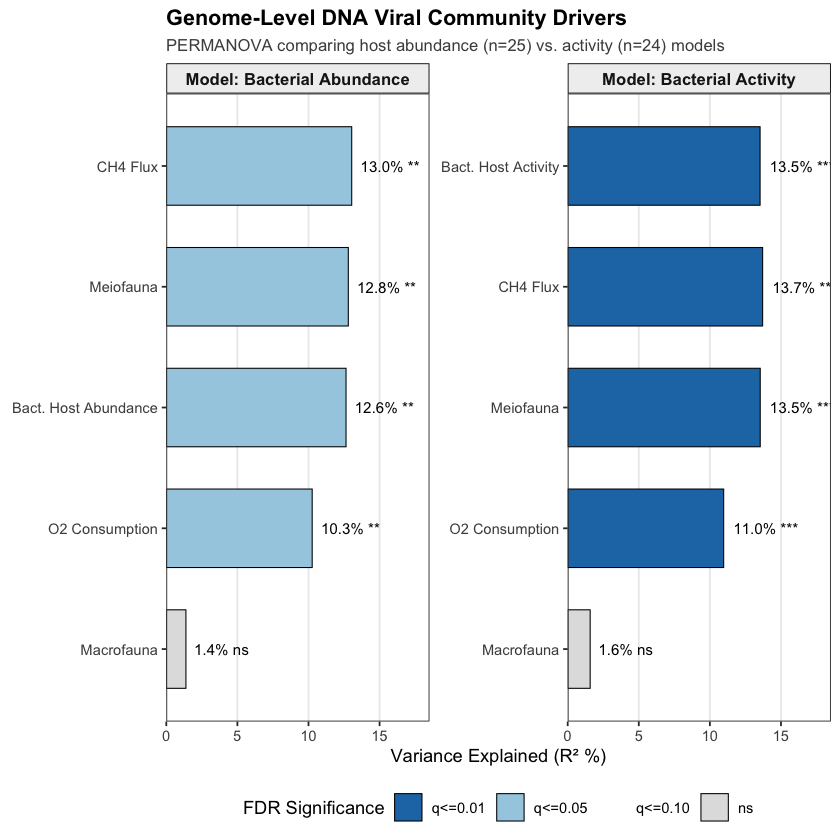

In [20]:
## =============================================================================
## Fig_2A:
##
## DNA viral community drivers: bacterial abundance vs activity
## Depth-robust PERMANOVA drivers of DNA viral composition (genome),
## both bacterial host proxies (abundance vs activity) tested in SEPARATE models.
## =============================================================================

# Key design: bacterial abundance composition and activity composition are collinear,
# so they are tested in separate models (not stacked). Each model = infauna (macrofauna and 
# meiofauna + fluxes (CH4 and O2) + one host proxy. Responses are relative abundance (depth-independent).
# Genome-level is primary. Significance is reported as p-values and adjusted p-values 
# using Benjamini-Hochberg (FDR <= 0.05). The data are transformed using "Hellinger" and
# Bray-Curtis as dissimilarity distance.
# Treatment order: Unmanip, HMM, HM, LM.
##############################################################


library(vegan)
library(dplyr)
library(tidyr)
library(ggplot2)
library(tibble)
library(patchwork)
library(scales)

PROJ <- "path/"

if (!dir.exists(PROJ)) PROJ <- "."
PROJ <- normalizePath(PROJ, mustWork = TRUE)

dir.create(file.path(PROJ, "outputs", "figures"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(PROJ, "outputs", "tables"),  recursive = TRUE, showWarnings = FALSE)

knitr::opts_chunk$set(echo = TRUE, message = FALSE, warning = FALSE,
                      fig.path = "outputs/figures/", dpi = 300)

TRT_ORDER <- c("Unmanip","HMM","HM","LM")
TRT_COL   <- c(Unamip="#238B45", HMM="#B15928", HM="#4393C3", LM="#D6604D")

## 1. DNA viral genomes (relative abundance)

dv <- read.table("data/DNA_Viruses119.txt", header=TRUE, sep="\t", row.names=1, check.names=FALSE)
vmat <- as.matrix(dv)
genome_rel <- decostand(t(vmat), "total")

## 2. Host composition axes (relativized from full genus matrices)

mkcomp <- function(path){
  b <- read.table(path, header=TRUE, sep="\t", check.names=FALSE, quote="", fill=TRUE)
  if ("Genus" %in% colnames(b)) { rownames(b)<-make.unique(as.character(b$Genus)); b$Genus<-NULL }
  else { rownames(b)<-make.unique(as.character(b[[1]])); b[[1]]<-NULL }
  scol <- grep("^(Unmanip|HM|HMM|LM)[ _]", colnames(b), value=TRUE)
  m <- as.matrix(sapply(b[,scol], function(x) as.numeric(as.character(x))))
  rownames(m) <- rownames(b); colnames(m) <- gsub(" ","_",scol); m[is.na(m)] <- 0
  pco <- cmdscale(vegdist(decostand(decostand(t(m),"total"),"hellinger"),"bray"), k=1)
  data.frame(Sample=rownames(as.matrix(pco)), comp=as.numeric(pco))
}
ba <- mkcomp("data/Bacteria_abundance_metagenome.txt"); names(ba)[2] <- "BactAbund_PC1"
bt <- mkcomp("data/Abundance_Transcript_bacteria.txt");  names(bt)[2] <- "BactActiv_PC1"

## 3. Environment + Infauna (full outer join with `all = TRUE`)

env <- read.delim("data/Master_table_short.txt", header = TRUE, sep = "\t")
env$Group <- factor(env$Group, levels=TRT_ORDER)
env <- merge(env, ba, by="Sample", all = TRUE)
env <- merge(env, bt, by="Sample", all = TRUE)

# Common predictors
common_pred <- c("Meiofauna","Macrofauna","O2_Cons","CH4_Flux")

## 4. Genome-level PERMANOVA models

run_perm_sep <- function(rel, level, host){
  vars <- c(common_pred, host)
  m <- env[match(rownames(rel), env$Sample),]
  keep <- complete.cases(m[,vars])
  set.seed(1)
  f <- as.formula(paste("decostand(rel[keep,],\"hellinger\") ~", paste(vars, collapse="+")))
  a <- adonis2(f, data=m[keep,], by="margin", permutations=999)
  as.data.frame(a) %>% rownames_to_column("term") %>%
    filter(!term %in% c("Residual","Total")) %>%
    transmute(level=level, host_model=host, term, R2=round(R2,4), p=`Pr(>F)`, n=sum(keep))
}

perm <- bind_rows(
  run_perm_sep(genome_rel, "Genome", "BactAbund_PC1"),
  run_perm_sep(genome_rel, "Genome", "BactActiv_PC1")
)

perm <- perm %>%
  group_by(host_model) %>%
  mutate(p_BH = p.adjust(p, method = "BH")) %>%
  ungroup()

perm$sig <- ifelse(perm$p_BH <= 0.01, "q<=0.01",
             ifelse(perm$p_BH <= 0.05, "q<=0.05",
             ifelse(perm$p_BH <= 0.10, "q<=0.10", "ns")))

# Export table to disk
write.csv(perm, "outputs/tables/Table_PERMANOVA_separate_proxies.csv", row.names = FALSE)

# Print PERMANOVA summary table to console
cat("\n--- PERMANOVA Summary Table (Genome Level) ---\n")
print(as.data.frame(perm))

## 5. Plotting (Fig_2A)

perm_plot <- perm %>%
  mutate(
    term_clean = case_when(
      term == "BactAbund_PC1" ~ "Bact. Host Abundance",
      term == "BactActiv_PC1" ~ "Bact. Host Activity",
      term == "Meiofauna"     ~ "Meiofauna",
      term == "Macrofauna"    ~ "Macrofauna",
      term == "O2_Cons"       ~ "O2 Consumption",
      term == "CH4_Flux"      ~ "CH4 Flux",
      TRUE ~ term
    ),
    host_model_label = case_when(
      host_model == "BactAbund_PC1" ~ "Model: Bacterial Abundance",
      host_model == "BactActiv_PC1" ~ "Model: Bacterial Activity",
      TRUE ~ host_model
    ),
    sig_stars = case_when(
      p_BH <= 0.01 ~ "***",
      p_BH <= 0.05 ~ "**",
      p_BH <= 0.10 ~ "*",
      TRUE ~ "ns"
    )
  )

perm_plot$sig <- factor(perm_plot$sig, levels = c("q<=0.01", "q<=0.05", "q<=0.10", "ns"))

fig_2a <- ggplot(perm_plot, aes(x = reorder(term_clean, R2), y = R2 * 100, fill = sig)) +
  geom_col(width = 0.65, color = "black", linewidth = 0.3) +
  geom_text(aes(label = paste0(sprintf("%.1f", R2 * 100), "% ", sig_stars)), 
            hjust = -0.15, size = 3.2) +
  scale_fill_manual(
    values = c("q<=0.01" = "#1F78B4", "q<=0.05" = "#A6CEE3", "q<=0.10" = "#FDBF6F", "ns" = "#E0E0E0"),
    drop = FALSE,
    name = "FDR Significance"
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.35))) +
  coord_flip() +
  facet_wrap(~ host_model_label, scales = "free_y") +
  labs(
    x = NULL,
    y = "Variance Explained (R² %)",
    title = "Genome-Level DNA Viral Community Drivers",
    subtitle = "PERMANOVA comparing host abundance (n=25) vs. activity (n=24) models"
  ) +
  theme_bw(base_size = 11) +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    strip.background = element_rect(fill = "#F0F0F0", color = "black"),
    strip.text = element_text(face = "bold", size = 10),
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "grey30", size = 10)
  )

# Render plot in active graphical device
print(fig_2a)

# Save high-resolution outputs
ggsave("outputs/figures/Fig_2A_PERMANOVA.pdf", plot = fig_2a, width = 9, height = 4, dpi = 300)
ggsave("outputs/figures/Fig_2A_PERMANOVA.png", plot = fig_2a, width = 9, height = 4, dpi = 300)